In [2]:
#work dir
setwd("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/")

In [3]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(lme4)
  library(broom.mixed)
  library(ggplot2)
library(dplyr)
library(tidyr)
library(tibble)
#library(ggridges)
    library(stringr)
library(tidyverse)
library(lmerTest)
library(broom.mixed)
library(ComplexHeatmap)
library(circlize)

})


In [28]:
##LOAD DATA######
all_df_aug <- read.table("/home/mjehangir/telomere-sv-analysis/data/all_df_aug_final_2026.txt",
                           sep = "\t",
                           header = TRUE)
head(all_df_aug)


,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_DUP_log,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log,arm_size_mb,HAR_rate_per_Mb,HAR_Distribution
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,-1.710542,-1.448588,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-3.671910,124.3391,0.00804246,1
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,-2.474780,-1.942610,-2.47478,-1.710542,-2.474780,-6.7196807,-4.094308,NA,NA,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-5.330008,124.3391,0.00000000,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-1.710542,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-2.474780,-0.2645872,-6.638746,NA,NA,0


In [29]:
all_df_aug = all_df_aug %>% rename(aneu_loss = is_loss,
                     aneu_gain = is_gain)

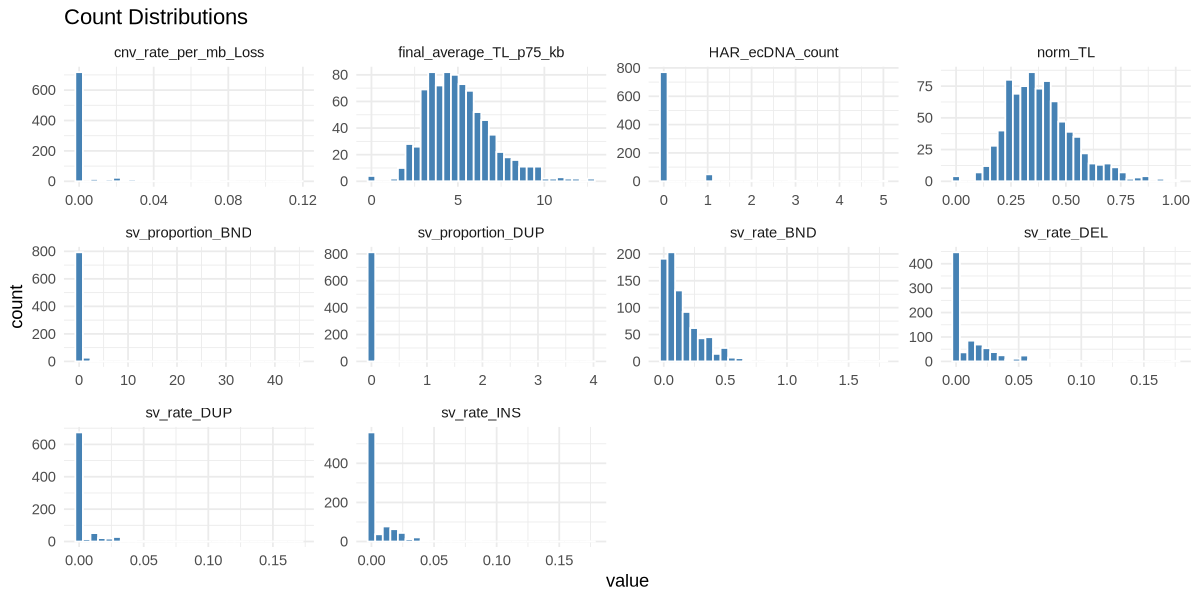

In [30]:

# plot distribution of different features by their count
vars_to_plot <- c("final_average_TL_p75_kb","norm_TL","sv_rate_INS","sv_rate_DUP","sv_proportion_DUP","sv_proportion_BND", "sv_rate_DEL","sv_rate_BND", "cnv_rate_per_mb_Loss", "HAR_ecDNA_count")

all_df_aug %>%
  dplyr::select(all_of(vars_to_plot)) %>%
  pivot_longer(everything()) %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~name, scales = "free") +
  theme_minimal() +
  labs(title = "Count Distributions")

In [31]:
# 2. log10 transformation of all SV and CNVs features to make consistent normalized distribution

# We create new columns with the suffix '_log' for each SV/CNV features
#a log transform with a minimum pseudocount/2 (so zeros don’t become -Inf)


all_vars <- c("sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INS", "sv_rate_INV",
              "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", 
              "sv_proportion_BND", "sv_proportion_DEL")


all_df_aug <- all_df_aug %>%
  dplyr::mutate(across(all_of(all_vars), 
                ~ log10(.x + (min(.x[.x > 0], na.rm = TRUE) / 2)), 
                .names = "{.col}_log"))


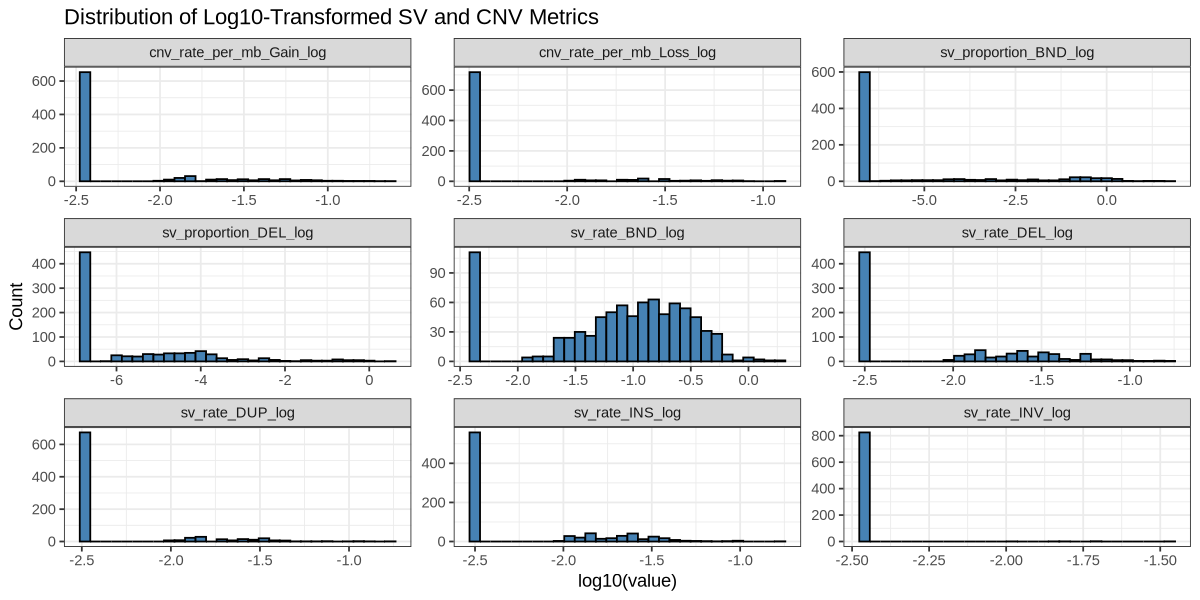

In [32]:
# Select log-transformed columns and reshape to long format
log_long <- all_df_aug %>%
  dplyr::select(contains("_log")) %>%
  pivot_longer(
    cols = everything(),
    names_to = "variable",
    values_to = "value"
  )

# Plot histograms
ggplot(log_long, aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  facet_wrap(~ variable, scales = "free") +
  theme_bw() +
  labs(
    title = "Distribution of Log10-Transformed SV and CNV Metrics",
    x = "log10(value)",
    y = "Count"
  )


In [33]:
colnames(all_df_aug)

[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"

In [36]:

# --- 1. SET UP VARIABLES ---
# List of genomic instability metrics to correlate against Telomere Length (norm_TL)
target_vars <- c("sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INV", "sv_rate_INS",
                 "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", "HAR_ecDNA_count","HAR_rate_per_Mb","HAR_Distribution", "aneu_loss", "aneu_gain", "ecDNA_estprop_sum", "has_ecdna","ecdna_max_amp","num_circuits")

# --- 2. CALCULATE CORRELATIONS ---
# Perform Spearman Correlation for each variable against Normalized Telomere Length.
# Spearman is used here to capture non-linear, monotonic relationships.
res_forest_all <- lapply(target_vars, function(v) {
  if(v %in% colnames(all_df_aug)) {
    # Conduct test; exact=FALSE prevents errors with tied ranks in large datasets
    cor_test <- cor.test(all_df_aug$norm_TL, all_df_aug[[v]], method = "spearman", exact = FALSE)
    
    data.frame(
      Feature = v,
      Rho = cor_test$estimate,
      Pval = cor_test$p.value
    )
  }
}) %>% bind_rows()

# --- 3. DATA CLEANING & CATEGORIZATION FOR PLOTTING ---
# Prepare the results by renaming variables and assigning significance levels.
plot_data <- res_forest_all %>%
  mutate(
    # Human-readable labels for the Y-axis
    Feature_Clean = case_when(
      Feature == "sv_rate_BND"        ~ "Translocation (BND)",
      Feature == "sv_rate_DEL"        ~ "Deletions (DEL)",
      Feature == "sv_rate_DUP"        ~ "Duplication (DUP)",
      Feature == "sv_rate_INV"        ~ "Inversion (INV)",
      Feature == "sv_rate_INS"        ~ "Insertion (INS)",
      Feature == "cnv_rate_per_mb_Loss" ~ "Large-scale Loss",
      Feature == "cnv_rate_per_mb_Gain" ~ "Large-scale Gain",
      Feature == "HAR_ecDNA_count"    ~ "HARs (ecDNA)",
      Feature == "aneuploidy"         ~ "Aneuploidy",
      Feature == "HAR_Distribution"         ~ "HAR_Distribution",
              Feature == "HAR_rate_per_Mb"         ~ "HAR_rate_per_Mb",


      TRUE ~ Feature
    ),
    
    # Group variables by biological category for easier visualization/coloring
    Bio_Group = case_when(
      grepl("HAR|ecDNA", Feature) ~ "Extrachromosomal (HARs)",
      grepl("sv", Feature)        ~ "Structural Variation (SV)",
      TRUE                        ~ "Copy Number Variation (CNV)"
    ),
    
    # Standardize p-value significance markers
    Signif_Label = case_when(
      Pval < 0.001 ~ "***",
      Pval < 0.01  ~ "**",
      Pval < 0.05  ~ "*",
      TRUE         ~ "n.s."
    )
  ) %>%
  # Sort by Rho value so the resulting plot shows a clear trend (e.g., Forest Plot)
  arrange(Rho) %>%
  mutate(Feature_Clean = factor(Feature_Clean, levels = unique(Feature_Clean)))

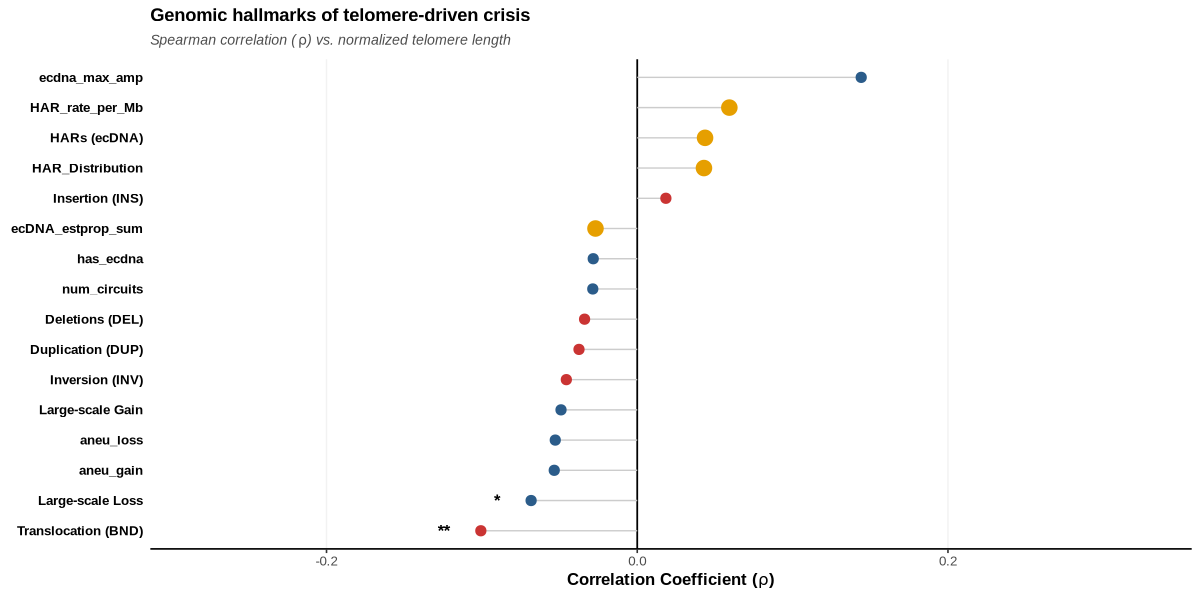

In [37]:
# --- 1. PREPARE PLOT AESTHETICS ---
plot_data <- plot_data %>%
  mutate(
    # Ensure Signif_Label matches your previous step's "n.s." string
    Clean_Signif = ifelse(Signif_Label == "n.s.", "", Signif_Label),
    
    # Assign Nature-inspired hex codes based on biological groups
    Final_Color = case_when(
      Bio_Group == "Extrachromosomal (HARs)" ~ "#E69F00", # Gold
      Bio_Group == "Structural Variation (SV)" ~ "#CA3433", # Red
      TRUE                                     ~ "#2B5C8A"  # Steel Blue (CNVs)
    ),
    
    # Visual emphasis: larger points for HARs/ecDNA
    Point_Size = ifelse(Bio_Group == "Extrachromosomal (HARs)", 4, 2.5)
  ) %>%
  # Re-confirming factor levels based on Rho for the forest plot gradient
  arrange(Rho) %>% 
  mutate(Feature_Clean = factor(Feature_Clean, levels = unique(Feature_Clean)))

# --- 2. GENERATE FOREST PLOT ---
ggplot(plot_data, aes(x = Rho, y = Feature_Clean)) +
  # Reference line at zero
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  
  # Lollipop segments: connecting the y-axis to the data point
  geom_segment(aes(x = 0, xend = Rho, yend = Feature_Clean),
               color = "grey80", linewidth = 0.4) +
  
  # Data points with dynamic color and size
  geom_point(aes(color = Final_Color, size = Point_Size)) +
  
  # Dynamic Significance Labels: Positioned based on Rho direction (+ or -)
  geom_text(aes(label = Clean_Signif, 
                x = Rho + ifelse(Rho < 0, -0.02, 0.02),
                hjust = ifelse(Rho < 0, 1, 0)), 
            size = 3.5, fontface = "bold") +
  
  # Use Identity scales to apply the hex codes and sizes defined in mutate()
  scale_color_identity() +
  scale_size_identity() +
  scale_x_continuous(expand = c(0.15, 0.15)) + 
  
  # Professional Labels using plotmath for symbols
  labs(
    title = "Genomic hallmarks of telomere-driven crisis",
    subtitle = expression(italic("Spearman correlation (") * rho * italic(") vs. normalized telomere length")),
    x = expression(bold("Correlation Coefficient (") * rho * bold(")")),
    y = NULL
  ) +
  
  # Minimalist Science Theme
  theme_classic(base_size = 10) +
  theme(
    axis.line.y  = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.y  = element_text(face = "bold", color = "black"),
    plot.title   = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 8.5, color = "grey30"),
    panel.grid.major.x = element_line(color = "grey95", linewidth = 0.4)
  )

In [42]:

# --- 1. BIN TELOMERE LENGTHS INTO QUINTILES ---
# Discretize continuous telomere length into 5 equal-sized groups 
# Note: ntile(1) = Shortest/Crisis, ntile(5) = Longest
all_df_aug <- all_df_aug %>%
  mutate(
   TL_Group = ntile(final_average_TL_p75_kb, 5),
   TL_Group = factor(TL_Group, 
                      levels = 1:5, 
                      labels = c("Very Short", "Short", "Intermediate", "Long", "Very Long"))
     # TL_Group = ntile(final_average_TL_p75_kb, 3),
   # TL_Group = factor(TL_Group, 
                 #     levels = 1:3, 
                    #  labels = c("Short", "Intermediate", "Long"))
  )

# --- 2. CALCULATE MEAN INTENSITY PER GROUP ---
# Aggregate instability metrics to see the "Broad Peak" shifts across TL groups
target_vars <- c("sv_rate_BND_log", "sv_rate_DEL_log", "sv_rate_DUP_log", 
                 "sv_rate_INS_log", "sv_rate_INV_log", "cnv_rate_per_mb_Loss_log",
                 "cnv_rate_per_mb_Gain_log", "HAR_ecDNA_count", "aneu_loss", "aneu_gain",
                 "HAR_Distribution", "HAR_rate_per_Mb", "ecDNA_estprop_sum")

heatmap_df <- all_df_aug %>%
  group_by(TL_Group) %>%
  # Use an anonymous function to calculate means while ignoring NA values
  summarise(across(all_of(target_vars), ~mean(.x, na.rm = TRUE)), .groups = "drop") %>%
  # Reshape for matrix transformation; clean variable names for the final plot
  pivot_longer(-TL_Group, names_to = "Variable", values_to = "Mean_Val") %>%
  mutate(Variable = gsub("_log", "", Variable))

# --- 3. TRANSFORM TO SCALED MATRIX FOR HEATMAP ---
# Convert to a matrix format and apply Z-score scaling by row (Variable-wise)
# This highlights the relative change of each feature across TL groups.
heatmap_mat <- heatmap_df %>%
  pivot_wider(names_from = TL_Group, values_from = Mean_Val) %>%
  tibble::column_to_rownames("Variable") %>%
  as.matrix()


In [43]:
head(all_df_aug, 2)
unique(all_df_aug$TL_Group)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log,arm_size_mb,HAR_rate_per_Mb,HAR_Distribution,TL_Group
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0,0.000000000,0,0.000000000,0.01612276,⋯,-1.448588,-2.47478,-2.47478,-2.474780,-6.719681,-6.638746,NA,NA,0,Intermediate
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0,0.001609727,0,0.008042525,0.00000000,⋯,-2.474780,-2.47478,-2.47478,-1.943328,-6.719681,-3.671910,124.3391,0.00804246,1,Intermediate


[1] Intermediate Very Short   Very Long    Short        Long        
Levels: Very Short Short Intermediate Long Very Long

In [44]:
# 1. Calculate One-Way ANOVA P-values for each row
sig_labels <- sapply(target_vars, function(v) {
    
    # This anova test compare if there the mean is different across the 5 groups
    fit <- aov(all_df_aug[[v]] ~ all_df_aug$TL_Group)
    # Extract the p-value from the summary
    p <- summary(fit)[[1]][["Pr(>F)"]][1]
    
    # Handle NAs or empty values
    if(is.na(p)) return("")
    
    # Return Significance Stars
    if(p < 0.001) return("***")
    else if(p < 0.01) return("**")
    else if(p < 0.05) return("*")
    else return("")
})

# 2. Place stars in the star_matrix
star_matrix <- matrix("", nrow = nrow(heatmap_mat), ncol = ncol(heatmap_mat))
star_matrix[, 5] <- sig_labels # Placing stars position

In [45]:
# # Scale values for heatmap
heatmap_scaled <- t(apply(heatmap_mat, 1, scale))
colnames(heatmap_scaled) <- colnames(heatmap_mat)
# Clean feature names: Replace underscores with spaces for publication-ready labels
rownames(heatmap_scaled) <- gsub("_", " ", rownames(heatmap_mat))

In [46]:
head(heatmap_scaled)

,Very Short,Short,Intermediate,Long,Very Long
sv rate BND,1.7218290,-0.8015314,-0.4630460,-0.0364006,-0.4208510
sv rate DEL,1.3837075,-0.2836771,-1.3532899,-0.1392810,0.3925405
sv rate DUP,1.3296772,0.7107890,-0.2134695,-0.8353645,-0.9916322
sv rate INS,0.8818094,-0.8448400,-0.9945665,-0.2495554,1.2071525
sv rate INV,0.8595713,-0.1226758,1.1231395,-0.5730997,-1.2869352
cnv rate per mb Loss,1.1760965,0.1924246,0.6325018,-0.7024637,-1.2985592


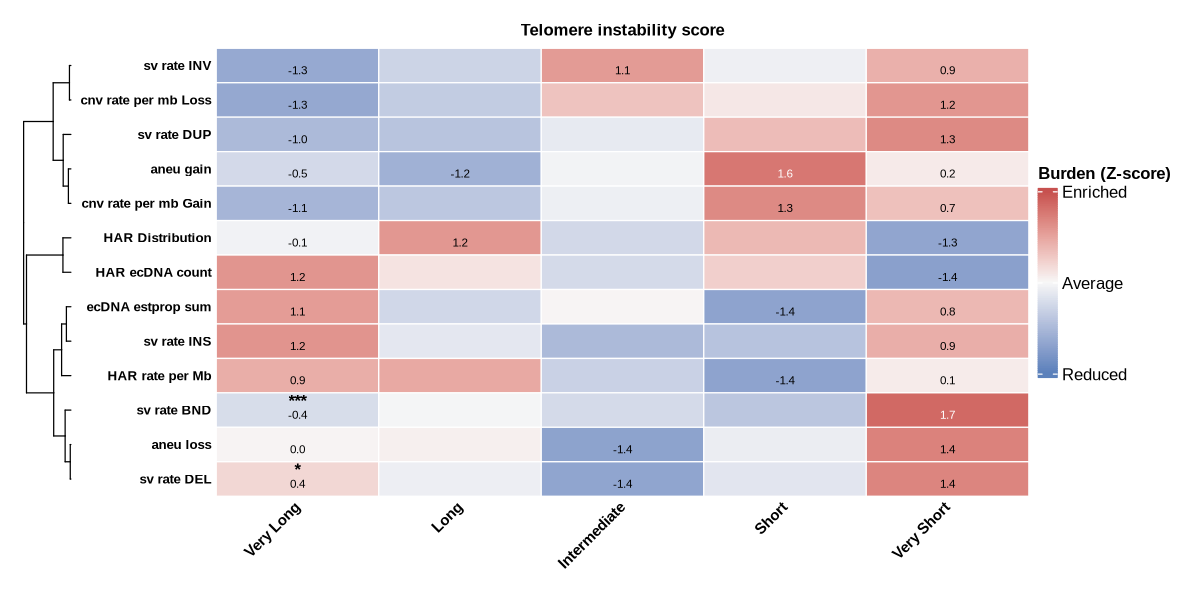

In [48]:
# --- 2. COLOR & THEME CONFIGURATION ---
# Diverging palette: Blue (Low/Stable) -> White (Average) -> Red (High/Crisis)

# Thresholds at +/- 2.5 prevent extreme outliers from compressing the mid-range colors.
col_fun <- colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "#F7F7F7", "#B2182B"))

# --- 3. HEATMAP CONSTRUCTION ---
h_plot <- Heatmap(heatmap_scaled, 
        name = "Z-score", 
        col = col_fun,
        
        # COLUMN LOGIC: Fixed Biological Gradient (Longest to Shortest)
        cluster_columns = FALSE, 
        column_order    = c("Very Long", "Long", "Intermediate", "Short", "Very Short"),
                #column_order    = c( "Long", "Intermediate", "Short"),

        # ROW LOGIC: Cluster features by similar response patterns
        cluster_rows             = TRUE,
        clustering_distance_rows = "pearson", 
        
        # GRID AESTHETICS
        rect_gp      = gpar(col = "white", lwd = 1), # White borders for "tile" look
        column_title = "Telomere instability score",
        column_title_gp = gpar(fontsize = 10, fontface = "bold"),
        
        # DYNAMIC CELL LABELING
        cell_fun = function(j, i, x, y, width, height, fill) {
            val <- heatmap_scaled[i, j]
            
            # A. Overlay Significance Stars (assumes star_matrix exists)
            if(exists("star_matrix") && star_matrix[i, j] != "") {
                grid.text(star_matrix[i, j], x, y + unit(2, "mm"), 
                          gp = gpar(fontsize = 10, fontface = "bold"))
            }
            
            # B. Selective Text: Only label "Extreme" values or "Anchor" cohorts
            is_extreme <- abs(val) > 1.0
            is_anchor  <- colnames(heatmap_scaled)[j] %in% c("Very Short", "Very Long")
            
            if(is_extreme | is_anchor) {
                grid.text(sprintf("%.1f", val), x, y - unit(1, "mm"), 
                          gp = gpar(fontsize = 7, 
                                    # Adaptive text color for contrast against dark tiles
                                    col = ifelse(abs(val) > 1.5, "white", "black")))
            }
        },
        
        # heamtmap LEGEND
        row_names_side   = "left",
        row_names_gp     = gpar(fontsize = 8, fontface = "bold"),
        column_names_gp  = gpar(fontsize = 9, fontface = "bold"),
        column_names_rot = 45,
        
        heatmap_legend_param = list(
            title = "Burden (Z-score)",
            at = c(-2, 0, 2),
            labels = c("Reduced", "Average", "Enriched"),
            legend_height = unit(4, "cm"),
            title_position = "topleft"
        )
)

# --- 4. heatmap plot ---
# Set plotting dimensions for Jupyter/RStudio
options(repr.plot.width = 10, repr.plot.height = 5)

draw(h_plot, 
     heatmap_legend_side = "right", 
     padding = unit(c(5, 5, 5, 5), "mm"))

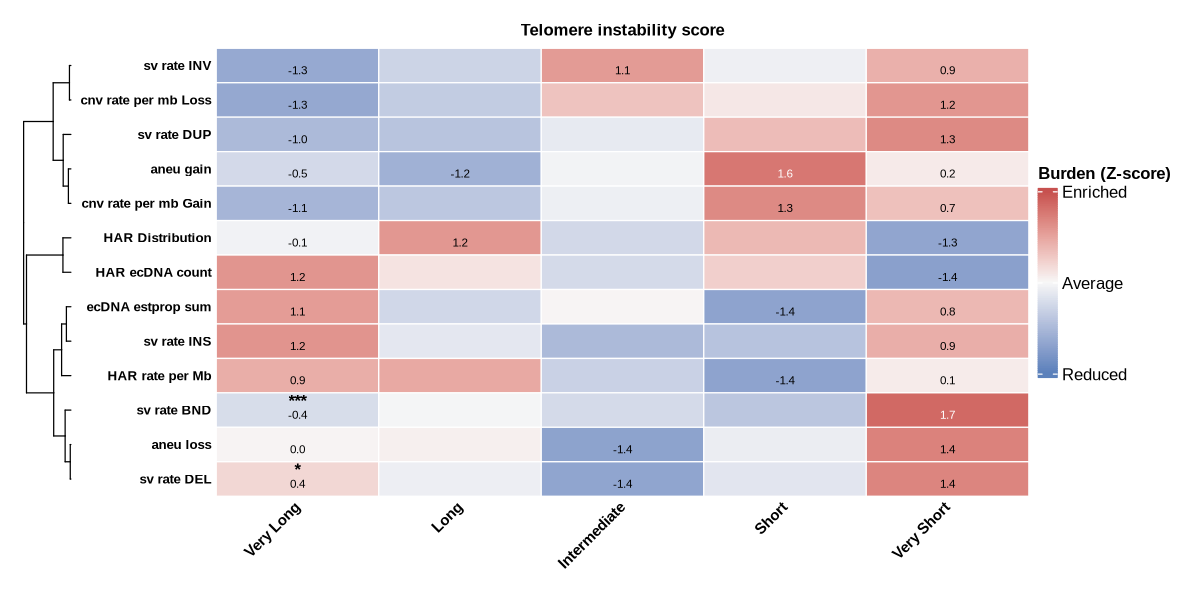

In [82]:
#pdf(
  #file = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_heatmap.pdf",
 # width = 10,
 # height = 4,
 # useDingbats = FALSE
#)

draw(
  h_plot,
  heatmap_legend_side = "right",
  padding = unit(c(5, 5, 5, 5), "mm")
)

#dev.off()


In [89]:
colnames(all_df_aug)

[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"          
[41] "TL_Group"

In [91]:
# --- Multivariate test ---
#Multivariate Analysis of Variance (MANOVA) 
# Adding sv_rate_DEL_log because it was significant in your univariate check

#Very-short telomere trending features 
dependent_vars_updated <- as.matrix(all_df_aug[, c("sv_rate_BND_log",
                                                   "sv_proportion_DEL_log"
                                                   )])

# --- 2. RUN UPDATED MANOVA ---
manova_updated <- manova(dependent_vars_updated ~ TL_Group, data = all_df_aug)

# This will now show how DEL and BND move together as a "Crisis Package"
summary(manova_updated, test = "Pillai")
summary.aov(manova_updated)

           Df   Pillai approx F num Df den Df    Pr(>F)    
TL_Group    4 0.039606   4.1719      8   1652 5.902e-05 ***
Residuals 826                                              
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response sv_rate_BND_log :
             Df Sum Sq Mean Sq F value    Pr(>F)    
TL_Group      4  10.02 2.50571  6.5194 3.628e-05 ***
Residuals   826 317.47 0.38435                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response sv_proportion_DEL_log :
             Df  Sum Sq Mean Sq F value Pr(>F)  
TL_Group      4   25.17  6.2918  2.5741 0.0365 *
Residuals   826 2019.01  2.4443                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [94]:
# --- Multivariate test ---
#Multivariate Analysis of Variance (MANOVA) 
# Adding sv_rate_DEL_log because it was significant in your univariate check

#Very-long telomere trending features 
dependent_vars_updated <- as.matrix(all_df_aug[, c("HAR_ecDNA_count",
                                                   "sv_rate_INS_log", "ecDNA_estprop_sum"
                                                   )])

# --- 2. RUN UPDATED MANOVA ---
manova_updated <- manova(dependent_vars_updated ~ TL_Group, data = all_df_aug)

# This will now show how DEL and BND move together as a "Crisis Package"
summary(manova_updated, test = "Pillai")
summary.aov(manova_updated)

           Df    Pillai approx F num Df den Df Pr(>F)
TL_Group    4 0.0057798   0.5985      8   1652 0.7798
Residuals 826                                        

 Response HAR_ecDNA_count :
             Df  Sum Sq Mean Sq F value Pr(>F)
TL_Group      4   0.428 0.10695  0.5326 0.7118
Residuals   826 165.878 0.20082               

 Response ecDNA_estprop_sum :
             Df  Sum Sq Mean Sq F value Pr(>F)
TL_Group      4    4726  1181.4  0.6329 0.6392
Residuals   826 1541945  1866.8               


In [90]:
# --- Multivariate test ---
#Multivariate Analysis of Variance (MANOVA) 
# Adding sv_rate_DEL_log because it was significant in your univariate check

#Very-Long telomere trending features witih
dependent_vars_updated <- as.matrix(all_df_aug[, c("sv_rate_BND_log",
                                                   "sv_rate_DEL_log", "aneu_loss")])

# --- 2. RUN UPDATED MANOVA ---
manova_updated <- manova(dependent_vars_updated ~ TL_Group, data = all_df_aug)

# This will now show how DEL and BND move together as a "Crisis Package"
summary(manova_updated, test = "Pillai")
summary.aov(manova_updated)

           Df   Pillai approx F num Df den Df  Pr(>F)  
TL_Group    4 0.036674   1.8749     12   1818 0.03305 *
Residuals 606                                          
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response sv_rate_BND_log :
             Df Sum Sq Mean Sq F value  Pr(>F)  
TL_Group      4   3.23 0.80760  2.7417 0.02787 *
Residuals   606 178.50 0.29456                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response sv_rate_DEL_log :
             Df  Sum Sq Mean Sq F value  Pr(>F)  
TL_Group      4   1.684 0.42109  1.9673 0.09795 .
Residuals   606 129.709 0.21404                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response aneu_loss :
             Df  Sum Sq  Mean Sq F value Pr(>F)
TL_Group      4  0.2383 0.059587  1.3186 0.2616
Residuals   606 27.3852 0.045190               

220 observations deleted due to missingness

In [95]:
# --- Multivariate test ---
#Multivariate Analysis of Variance (MANOVA) 
# Adding sv_rate_DEL_log because it was significant in your univariate check

#other features
dependent_vars_updated <- as.matrix(all_df_aug[, c("cnv_rate_per_mb_Gain_log",
                                                   "cnv_rate_per_mb_Loss_log", "sv_rate_DUP_log",
                                                   "aneu_gain", "aneu_loss",
                                                   "sv_rate_INV_log")])

# --- 2. RUN UPDATED MANOVA ---
manova_updated <- manova(dependent_vars_updated ~ TL_Group, data = all_df_aug)

# This will now show how DEL and BND move together as a "Crisis Package"
summary(manova_updated, test = "Pillai")
summary.aov(manova_updated)

           Df   Pillai approx F num Df den Df Pr(>F)
TL_Group    4 0.042437   1.0795     24   2416  0.359
Residuals 606                                       

 Response cnv_rate_per_mb_Gain_log :
             Df Sum Sq  Mean Sq F value Pr(>F)
TL_Group      4  0.369 0.092148   0.688 0.6004
Residuals   606 81.163 0.133932               

 Response cnv_rate_per_mb_Loss_log :
             Df Sum Sq Mean Sq F value Pr(>F)
TL_Group      4  0.467 0.11675  1.4779 0.2073
Residuals   606 47.874 0.07900               

 Response sv_rate_DUP_log :
             Df Sum Sq  Mean Sq F value Pr(>F)
TL_Group      4  0.166 0.041517  0.4054 0.8048
Residuals   606 62.061 0.102410               

 Response aneu_gain :
             Df  Sum Sq  Mean Sq F value Pr(>F)
TL_Group      4  0.2508 0.062709  1.3025 0.2677
Residuals   606 29.1763 0.048146               

 Response aneu_loss :
             Df  Sum Sq  Mean Sq F value Pr(>F)
TL_Group      4  0.2383 0.059587  1.3186 0.2616
Residuals   606 27.3852 0.045190               

 Response sv_rate_INV_log :
             Df  Sum Sq   Mean Sq F value Pr(>F)
TL_Group      4 0.01895 0.0047372  0.9643 0.4265
Residuals   606

In [3]:
# --- Save as PDF (vector, ideal for publication) ---
#ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_volcano.pdf",
 # plot = p,
 # width = 6,   # inches
  #height = 4,  # inches
  #units = "in",
  #device = "pdf"
#)

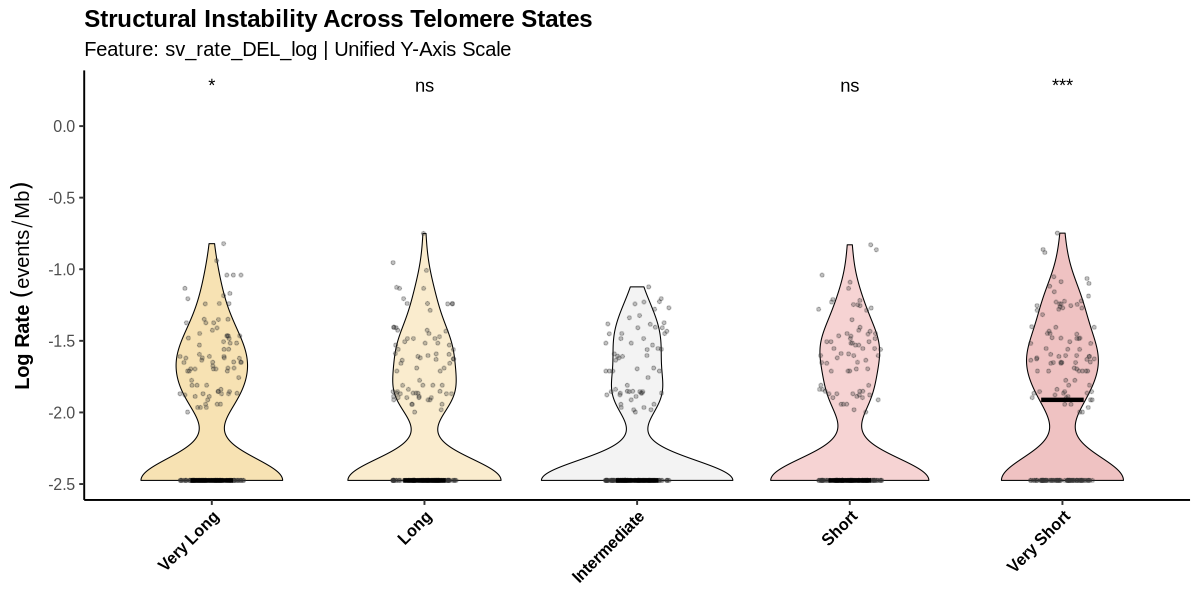

In [53]:
#Violin plot comparisons across telomere groups

library(ggpubr)
# --- 1. DATA prep ---
plot_simple <- all_df_aug %>%
  mutate(
    Q_val = ntile(norm_TL, 5),
    Cohort = case_when(
      Q_val == 5 ~ "Very Long",
      Q_val == 4 ~ "Long",
      Q_val == 3 ~ "Intermediate",
      Q_val == 2 ~ "Short",
      Q_val == 1 ~ "Very Short"
    ),
    Cohort = factor(Cohort, levels = c("Very Long", "Long", "Intermediate", "Short", "Very Short"))
  )

#Plot for SV deletions
# --- 2. the target feature to plot  ---
target_y <- "sv_rate_DEL_log" # ecdna_max_amp, sv_rate_DEL_log

# Define a global Y-limit so all your plots (DEL, BND, etc.) share the same scale
# Adjust these numbers based on your actual data range (e.g., -5 to 5)
y_limit_min <- min(plot_simple[[target_y]], na.rm = TRUE)
y_limit_max <- max(plot_simple[[target_y]], na.rm = TRUE) + 1 # +1 for star room

p <- ggplot(plot_simple, aes(x = Cohort, y = .data[[target_y]], fill = Cohort)) +
  # A. The Violin & Jitter
  geom_violin(alpha = 0.3, color = "black", linewidth = 0.3, trim = TRUE) +
  geom_jitter(width = 0.15, alpha = 0.3, size = 0.8, color = "grey20") +
  
  # B. Median Stability Line
  stat_summary(fun = median, geom = "crossbar", width = 0.2, color = "black") +
  
  # C. STATISTICAL COMPARISONS (Wilcoxon)
  stat_compare_means(
    ref.group = "Intermediate", 
    method = "wilcox.test",
    label = "p.signif", 
    label.y = y_limit_max * 0.95 # Consistent star height
  ) +
  
  # D. UNIFIED SCALE (Crucial for comparison)
  # Using coord_cartesian allows us to zoom without removing data points
  coord_cartesian(ylim = c(y_limit_min, y_limit_max)) +
  
  # E. STYLED SCALES & THEME
  scale_fill_manual(values = c(
    "Very Long" = "#E69F00", "Long" = "#F0C15B", 
    "Intermediate" = "#D9D9D9", "Short" = "#E26D6D", "Very Short" = "#CA3433"
  )) +
  
  labs(
    title = "Structural Instability Across Telomere States",
    subtitle = paste("Feature:", target_y, "| Unified Y-Axis Scale"),
    x = NULL,
    y = expression(bold("Log Rate") ~ (events / Mb))
  ) +
  
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(color = "black", face = "bold", angle = 45, hjust = 1),
    plot.title = element_text(face = "bold")
  )

print(p)

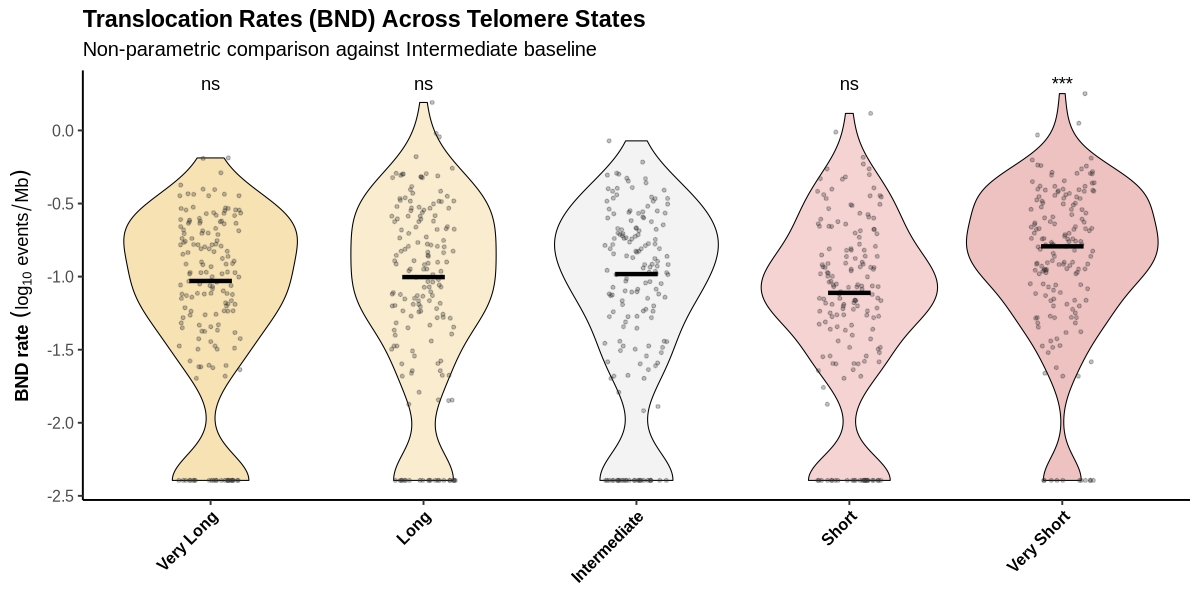

In [54]:
#For BNDs 

# --- 1. plot data prep ---
# Using mutate across to handle factor levels more cleanly
plot_simple <- all_df_aug %>%
  mutate(
    Q_val = ntile(norm_TL, 5),
    Cohort = case_when(
      Q_val == 5 ~ "Very Long",
      Q_val == 4 ~ "Long",
      Q_val == 3 ~ "Intermediate",
      Q_val == 2 ~ "Short",
      Q_val == 1 ~ "Very Short"
    ),
    Cohort = factor(Cohort, levels = c("Very Long", "Long", "Intermediate", "Short", "Very Short"))
  )

# Define target variable once to avoid typos in multiple places
target_var <- "sv_rate_BND_log"

# --- 2. THE VIOLIN VISUAL WITH STATS ---
p <- ggplot(plot_simple, aes(x = Cohort, y = .data[[target_var]], fill = Cohort)) +
  # A. The Violin (Distribution Density)
  geom_violin(alpha = 0.3, color = "black", linewidth = 0.3, trim = TRUE) +
  
  # B. Individual Patients (Raw Data)
  geom_jitter(width = 0.15, alpha = 0.3, size = 0.8, color = "grey20") +
  
  # C. Central Tendency (Median)
  stat_summary(fun = median, geom = "crossbar", width = 0.2, color = "black") +
  
  # D. SIGNIFICANCE STARS (Non-parametric Wilcoxon)
  # Dynamically calculate label height to stay above the max data point
  stat_compare_means(
    ref.group = "Intermediate", 
    method = "wilcox.test",
    label = "p.signif", 
    hide.ns = FALSE, 
    label.y = max(plot_simple[[target_var]], na.rm = TRUE) * 1.1 
  ) +
  
  # E. Color Palette (Crisis Gradient)
  scale_fill_manual(values = c(
    "Very Long" = "#E69F00", "Long" = "#F0C15B", 
    "Intermediate" = "#D9D9D9", "Short" = "#E26D6D", "Very Short" = "#CA3433"
  )) +
  
  # F. Professional Labels
  labs(
    title = "Translocation Rates (BND) Across Telomere States",
    subtitle = "Non-parametric comparison against Intermediate baseline",
    x = NULL,
    y = expression(bold("BND rate") ~ (log[10] ~ events / Mb))
  ) +
  
  # G. Theme Refinement
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(color = "black", face = "bold", angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", size = 14),
    axis.title.y = element_text(size = 11)
  )

print(p)

In [55]:
# --- Save as PDF (vector, ideal for publication) ---
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_sinaplot.pdf",
  plot = p,
  width = 8,   # inches
  height = 6,  # inches
  units = "in",
  device = "pdf"
)

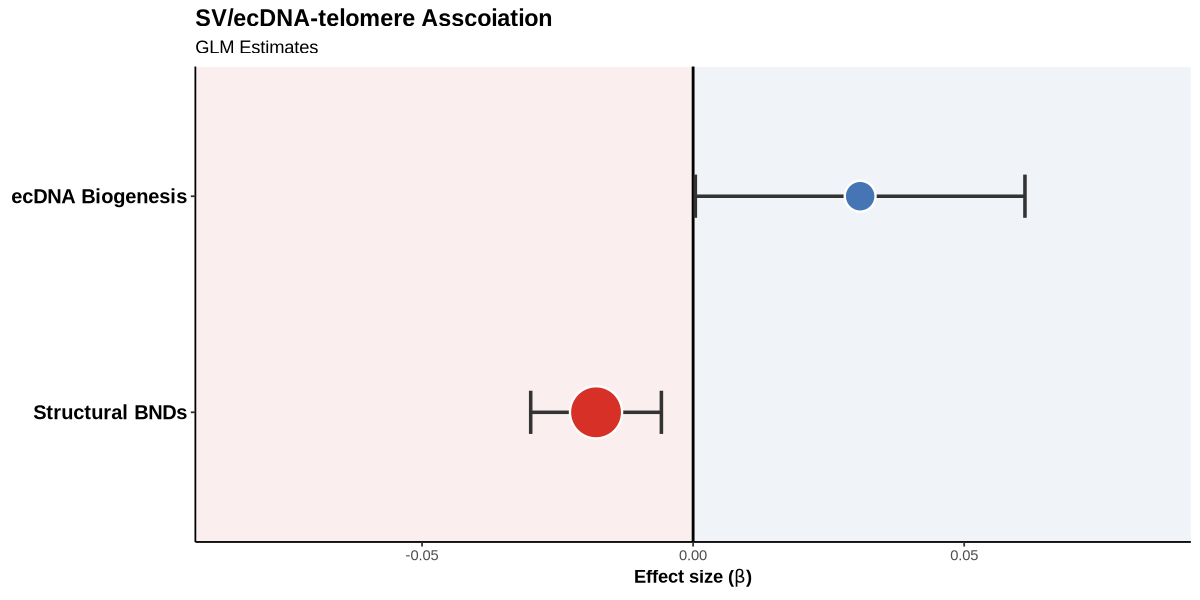

In [60]:
#GLM model based statsitics and forest plot

# --- 1. DEFINE SPECIFIC RAW TARGETS ---

# We test whether SV BND  and HAR_ecDNA counts affect telomere

focused_targets <- c("sv_rate_BND",  "HAR_ecDNA_count")

# --- 2. EXECUTE MODELS ---
glm_focused_results <- lapply(focused_targets, function(v) {
  if(!(v %in% colnames(all_df_aug))) return(NULL)
  
  # Ensure data is non-negative
  current_data <- all_df_aug %>% filter(.data[[v]] >= 0)

    fit <- glm(reformulate("TL_zscore", response = v),
           data = current_data)
    
  s <- summary(fit)$coefficients
  data.frame(
    Variable = v,
    Estimate = s["TL_zscore", "Estimate"],
    StdErr   = s["TL_zscore", "Std. Error"],
    Pval     = s["TL_zscore", "Pr(>|t|)"]
  )
}) %>% bind_rows()

# --- 3. CLEAN & PREP FOR PLOTTING ---
plot_data_focused <- glm_focused_results %>%
  mutate(
    Label = case_when(
      Variable == "sv_rate_BND" ~ "Structural BNDs",
      Variable == "cnv_rate_per_mb_Loss" ~ "CNV Loss",
      Variable == "HAR_ecDNA_count" ~ "ecDNA Biogenesis",
      TRUE ~ Variable
    ),
    Lower = Estimate - (1.96 * StdErr),
    Upper = Estimate + (1.96 * StdErr),
    Label = factor(Label, levels = Label[order(Estimate)])
  )
    # Define dynamic X-axis limits for symmetry
max_val <- max(abs(c(plot_data_focused$Lower, plot_data_focused$Upper)), na.rm = TRUE) * 1.5

p_final <- ggplot(plot_data_focused, aes(x = Estimate, y = Label)) +
  # Background  for Crisis vs Stability
  annotate("rect", xmin = -max_val, xmax = 0, ymin = -Inf, ymax = Inf, fill = "#d73027", alpha = 0.08) +
  annotate("rect", xmin = 0, xmax = max_val, ymin = -Inf, ymax = Inf, fill = "#4575b4", alpha = 0.08) +
  
  geom_vline(xintercept = 0, linetype = "solid", color = "black", linewidth = 0.8) +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.2, color = "grey20", linewidth = 1) +
  geom_point(aes(fill = Estimate < 0, size = pmin(-log10(Pval), 10)), shape = 21, color = "white", stroke = 1) +
  
  # plot labels
  scale_fill_manual(values = c("TRUE" = "#d73027", "FALSE" = "#4575b4")) +
  scale_size_continuous(range = c(8, 14)) +
  scale_x_continuous(limits = c(-max_val, max_val), expand = c(0,0)) +
  
  labs(
    title = "SV/ecDNA-telomere Asscoiation ",
    subtitle = "GLM Estimates",
    x = expression(bold("Effect size (") * beta * bold(")")),
    y = NULL
  ) +
  theme_classic() +
  theme(
    axis.text.y = element_text(face = "bold", size = 12, color = "black"),
    plot.title = element_text(face = "bold", size = 14),
    legend.position = "none"
  )

print(p_final)

In [64]:
head(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log,arm_size_mb,HAR_rate_per_Mb,HAR_Distribution,TL_Group
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,-1.448588,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0,Intermediate
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-3.671910,124.3391,0.00804246,1,Intermediate
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,-1.942610,-2.47478,-1.710542,-2.474780,-6.7196807,-4.094308,NA,NA,0,Very Short
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-5.330008,124.3391,0.00000000,0,Very Short
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-1.710542,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0,Very Short
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-2.474780,-0.2645872,-6.638746,NA,NA,0,Intermediate


In [61]:
# --- Save as PDF (vector, ideal for publication) ---
#ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_glm_forestplot.pdf",
#  plot = p,
#  width = 15,   # inches
#  height = 5,  # inches
 # units = "in",
# device = "pdf"
#)

In [76]:

# --- 1. inlcude all SV/CNVs ecDNA features (Use raw rates, not _log) ---


all_targets <- c(
  "sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INV", "sv_rate_INS",
  "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", 
  "HAR_ecDNA_count", "aneu_gain","aneu_loss", "HAR_rate_per_Mb","HAR_Distribution","ecDNA_estprop_sum"
)

# --- 2. EXECUTE MODELS ---
glm_all_results <- lapply(all_targets, function(v) {
  if(!(v %in% colnames(all_df_aug))) return(NULL)
  
  current_data <- all_df_aug %>% filter(.data[[v]] >= 0)
  
  # Fit the model
  fit <- tryCatch({
    glm(as.formula(paste(v, "~ TL_zscore")), 
        data      = current_data, 
        family    = quasipoisson(link = "log"),
        na.action = na.exclude)
  }, error = function(e) return(NULL))

  if(is.null(fit)) return(NULL)


  s <- summary(fit)$coefficients
  if("TL_zscore" %in% rownames(s)) {
    data.frame(
      Variable = v,
      Estimate = s["TL_zscore", "Estimate"],
      StdErr   = s["TL_zscore", "Std. Error"],
      Pval     = s["TL_zscore", "Pr(>|t|)"]
    )
  }
}) %>% bind_rows()

# --- 3. DATA CLEANING & RANKING ---
plot_data_all <- glm_all_results %>%
  mutate(
    # labels for the Forest Plot
    Label = Variable %>% 
      gsub("sv_rate_", "SV: ", .) %>% 
      gsub("cnv_rate_per_mb_", "CNV: ", .) %>%
      gsub("HAR_ecDNA_count", "ecDNA Count", .) %>%
      gsub("HAR_rate_per_Mb", "ecDNA Density", .) %>%
      gsub("aneuploidy", "Aneuploidy", .),
    
    Lower = Estimate - (1.96 * StdErr),
    Upper = Estimate + (1.96 * StdErr),
    Label = factor(Label, levels = Label[order(Estimate)])
  )


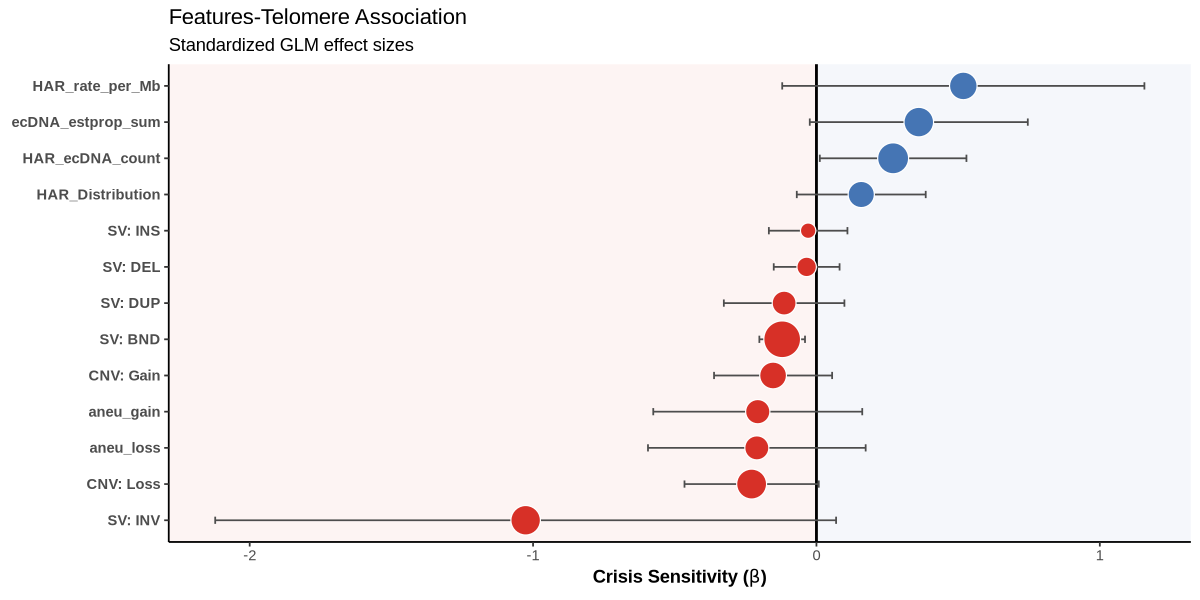

In [77]:
# --- 3. DATA CLEANING & RANKING ---
plot_data_all <- glm_all_results %>%
  mutate(
    # Human-readable labels
    Label = Variable %>% 
      gsub("sv_rate_", "SV: ", .) %>% 
      gsub("cnv_rate_per_mb_", "CNV: ", .) %>%
      gsub("_log", "", .),
    Lower = Estimate - (1.96 * StdErr),
    Upper = Estimate + (1.96 * StdErr),
    # Sort by Estimate magnitude
    Label = factor(Label, levels = Label[order(Estimate)])
  )

# --- 4. THE ALL-VARIABLE FOREST PLOT ---
ggplot(plot_data_all, aes(x = Estimate, y = Label)) +
  # Visual Zones
  annotate("rect", xmin = -Inf, xmax = 0, ymin = -Inf, ymax = Inf, fill = "#d73027", alpha = 0.05) +
  annotate("rect", xmin = 0, xmax = Inf, ymin = -Inf, ymax = Inf, fill = "#4575b4", alpha = 0.05) +
  
  geom_vline(xintercept = 0, color = "black", size = 0.8) +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.2, color = "grey30") +
  geom_point(aes(fill = Estimate < 0, size = -log10(Pval)), shape = 21, color = "white") +
  
  scale_fill_manual(values = c("TRUE" = "#d73027", "FALSE" = "#4575b4")) +
  scale_size_continuous(range = c(4, 10)) +
  
  labs(
    title = "Features-Telomere Association",
    subtitle = "Standardized GLM effect sizes",
    x = expression(bold("Crisis Sensitivity (") * beta * bold(")")), y = NULL
  ) +
  theme_classic() +
  theme(axis.text.y = element_text(face = "bold"), legend.position = "none")

In [78]:
head(all_df_aug)
colnames(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log,arm_size_mb,HAR_rate_per_Mb,HAR_Distribution,TL_Group
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,-1.448588,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0,Intermediate
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-3.671910,124.3391,0.00804246,1,Intermediate
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,-1.942610,-2.47478,-1.710542,-2.474780,-6.7196807,-4.094308,NA,NA,0,Very Short
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-5.330008,124.3391,0.00000000,0,Very Short
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-1.710542,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0,Very Short
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-2.47478,-2.474780,-2.474780,-0.2645872,-6.638746,NA,NA,0,Intermediate


[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"          
[41] "TL_Group"